# Hoja de Trabajo 6 – Task 1 (Entrega Parcial)
**CC2017 – Modelación y Simulación, Sección 10**

- José Gerardo Ruiz García – 23719
- Gerardo André Fernández Cruz – 23763
- Juan Diego Solís Martínez – 23720

Modelo de competencia entre dos plataformas (Lotka-Volterra competitivo):

$$\dot x = r_1\,x\,(1 - x - \alpha_{12}\,y), \qquad \dot y = r_2\,y\,(1 - y - \alpha_{21}\,x)$$

Este notebook solo hace cálculos analíticos/numéricos y gráficas de apoyo para el Task 1. **No se integra el sistema** (no se usa `solve_ivp`). SymPy se usa únicamente para **verificar** las derivaciones que hicimos a mano.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Semilla fija para reproducibilidad (requisito de la hoja).
# En el Task 1 no usamos números aleatorios, pero la dejamos fija desde ya para el Task 2.
np.random.seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']

## Parámetros del grupo
Conjunto $= ((g-1) \bmod 4) + 1$, $\;r_1 = 1$, $\;r_2 = 0.5 + 0.1\,((g-1) \bmod 5)$

In [2]:
g = 5  # número de grupo

# Tabla de conjuntos de la hoja: conjunto -> (alpha12, alpha21)
conjuntos = {1: (0.5, 0.6), 2: (1.4, 1.5), 3: (0.6, 1.5), 4: (1.5, 0.6)}

conjunto = ((g - 1) % 4) + 1
a12, a21 = conjuntos[conjunto]
r1 = 1.0
r2 = 0.5 + 0.1 * ((g - 1) % 5)

print(f"Grupo: {g}")
print(f"Conjunto: {conjunto}  ->  alpha12 = {a12}, alpha21 = {a21}")
print(f"r1 = {r1}, r2 = {r2:.1f}")

Grupo: 5
Conjunto: 1  ->  alpha12 = 0.5, alpha21 = 0.6
r1 = 1.0, r2 = 0.9


In [3]:
def campo(x, y):
    # Lado derecho del sistema: (x', y')
    dx = r1 * x * (1 - x - a12 * y)
    dy = r2 * y * (1 - y - a21 * x)
    return dx, dy

## Task 1.1 – Equilibrios
Fórmulas derivadas a mano:
- $(0,0)$, $(1,0)$, $(0,1)$
- Interior: $x^* = \dfrac{1-\alpha_{12}}{1-\alpha_{12}\alpha_{21}}$, $\quad y^* = \dfrac{1-\alpha_{21}}{1-\alpha_{12}\alpha_{21}}$ (requiere $\alpha_{12}\alpha_{21}\neq 1$)

In [4]:
D = 1 - a12 * a21              # denominador común del equilibrio interior
xs = (1 - a12) / D              # x* = (1 - a12)/(1 - a12*a21)
ys = (1 - a21) / D              # y* = (1 - a21)/(1 - a12*a21)

equilibrios = {
    '(0,0)': (0.0, 0.0),
    '(1,0)': (1.0, 0.0),
    '(0,1)': (0.0, 1.0),
    '(x*,y*)': (xs, ys),
}

print(f"D = 1 - a12*a21 = {D:.4f}")
for nombre, (x0, y0) in equilibrios.items():
    factible = (x0 >= 0) and (y0 >= 0)   # factible = coordenadas no negativas
    print(f"{nombre:8s} = ({x0:.4f}, {y0:.4f})   factible: {'sí' if factible else 'no'}")

# Comprobación: el interior debe estar sobre las dos rectas x + a12*y = 1 y y + a21*x = 1
print("\nx* + a12*y* =", round(xs + a12 * ys, 10), "  y* + a21*x* =", round(ys + a21 * xs, 10))
# Comprobación: en cada equilibrio el campo debe ser (0, 0)
print("Campo en cada equilibrio:", {k: tuple(round(v, 12) + 0.0 for v in campo(*p)) for k, p in equilibrios.items()})

D = 1 - a12*a21 = 0.7000
(0,0)    = (0.0000, 0.0000)   factible: sí
(1,0)    = (1.0000, 0.0000)   factible: sí
(0,1)    = (0.0000, 1.0000)   factible: sí
(x*,y*)  = (0.7143, 0.5714)   factible: sí

x* + a12*y* = 1.0   y* + a21*x* = 1.0
Campo en cada equilibrio: {'(0,0)': (0.0, 0.0), '(1,0)': (0.0, 0.0), '(0,1)': (0.0, 0.0), '(x*,y*)': (0.0, 0.0)}


**Verificación con SymPy** de la solución del sistema lineal (solo para comprobar lo hecho a mano, Task 1.1a):

In [5]:
x, y, A12, A21 = sp.symbols('x y alpha12 alpha21')
sol = sp.solve([x + A12 * y - 1, y + A21 * x - 1], [x, y], dict=True)[0]
print("x* =", sp.simplify(sol[x]))
print("y* =", sp.simplify(sol[y]))

x* = (alpha12 - 1)/(alpha12*alpha21 - 1)
y* = (alpha21 - 1)/(alpha12*alpha21 - 1)


## Task 1.2 – Jacobiana y clasificación
Derivando cada ecuación respecto a cada variable:
$$J(x,y)=\begin{pmatrix} r_1(1-2x-\alpha_{12}y) & -r_1\alpha_{12}x \\ -r_2\alpha_{21}y & r_2(1-2y-\alpha_{21}x)\end{pmatrix}$$
Con $\tau = J_{11}+J_{22}$, $\;\Delta = J_{11}J_{22}-J_{12}J_{21}$, $\;\lambda = \dfrac{\tau \pm \sqrt{\tau^2-4\Delta}}{2}$.

In [6]:
def jacobiana(x, y):
    J11 = r1 * (1 - 2 * x - a12 * y)   # d(x')/dx
    J12 = -r1 * a12 * x                # d(x')/dy
    J21 = -r2 * a21 * y                # d(y')/dx
    J22 = r2 * (1 - 2 * y - a21 * x)   # d(y')/dy
    return np.array([[J11, J12], [J21, J22]])


def clasificar(tau, delta, disc, tol=1e-12):
    # Clasificación con el plano traza-determinante
    if delta < -tol:
        return 'silla'
    tipo = 'nodo' if disc >= -tol else 'foco'
    if abs(tau) < tol:
        return 'centro'
    return f"{tipo} {'estable' if tau < 0 else 'inestable'}"


In [7]:
resultados = {}
for nombre, (x0, y0) in equilibrios.items():
    J = jacobiana(x0, y0)
    tau = np.trace(J)                                # traza
    delta = J[0, 0] * J[1, 1] - J[0, 1] * J[1, 0]   # determinante (ojo: con signo MENOS)
    disc = tau**2 - 4 * delta                        # discriminante
    lam = np.linalg.eigvals(J)                       # valores propios (comprobación numérica)
    resultados[nombre] = (tau, delta)
    print(f"Equilibrio {nombre}")
    print("  J =", (np.round(J, 4) + 0.0).tolist())   # + 0.0 solo quita los "-0.0" al imprimir
    print(f"  tau = {tau:.4f}, Delta = {delta:.4f}, tau^2-4Delta = {disc:.4f}")
    print(f"  lambda = {np.round(np.sort(lam.real), 4)}  ->  {clasificar(tau, delta, disc)}\n")

Equilibrio (0,0)
  J = [[1.0, 0.0], [0.0, 0.9]]
  tau = 1.9000, Delta = 0.9000, tau^2-4Delta = 0.0100
  lambda = [0.9 1. ]  ->  nodo inestable

Equilibrio (1,0)
  J = [[-1.0, -0.5], [0.0, 0.36]]
  tau = -0.6400, Delta = -0.3600, tau^2-4Delta = 1.8496
  lambda = [-1.    0.36]  ->  silla

Equilibrio (0,1)
  J = [[0.5, 0.0], [-0.54, -0.9]]
  tau = -0.4000, Delta = -0.4500, tau^2-4Delta = 1.9600
  lambda = [-0.9  0.5]  ->  silla

Equilibrio (x*,y*)
  J = [[-0.7143, -0.3571], [-0.3086, -0.5143]]
  tau = -1.2286, Delta = 0.2571, tau^2-4Delta = 0.4808
  lambda = [-0.961  -0.2676]  ->  nodo estable



En los ejes la jacobiana es triangular, así que los valores propios salen directo de la diagonal:
$(0,0)\to r_1, r_2$; $\;(1,0)\to -r_1,\ r_2(1-\alpha_{21})$; $\;(0,1)\to r_1(1-\alpha_{12}),\ -r_2$.

In [8]:
print("(0,0):", r1, r2)
print("(1,0):", -r1, round(r2 * (1 - a21), 4))
print("(0,1):", round(r1 * (1 - a12), 4), -r2)

(0,0): 1.0 0.9
(1,0): -1.0 0.36
(0,1): 0.5 -0.9


**Verificación con SymPy** de la jacobiana derivada a mano (Task 1.2a):

In [9]:
R1, R2 = sp.symbols('r1 r2', positive=True)
F = sp.Matrix([R1 * x * (1 - x - A12 * y), R2 * y * (1 - y - A21 * x)])
J_sym = sp.simplify(F.jacobian([x, y]))
J_mano = sp.Matrix([[R1 * (1 - 2*x - A12*y), -R1*A12*x], [-R2*A21*y, R2*(1 - 2*y - A21*x)]])
print("J (SymPy) =", J_sym)
print("¿Coincide con la derivada a mano?", sp.simplify(J_sym - J_mano) == sp.zeros(2, 2))

J (SymPy) = Matrix([[r1*(-alpha12*y - 2*x + 1), -alpha12*r1*x], [-alpha21*r2*y, r2*(-alpha21*x - 2*y + 1)]])
¿Coincide con la derivada a mano? True


### Task 1.2c – Plano traza-determinante

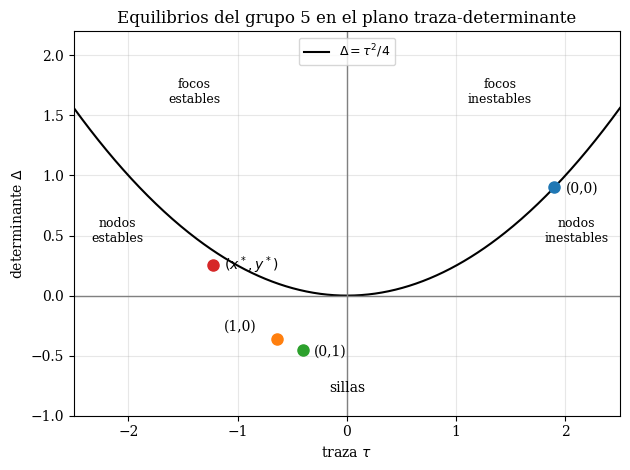

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))
t = np.linspace(-2.5, 2.5, 400)
ax.plot(t, t**2 / 4, 'k', lw=1.5, label=r'$\Delta=\tau^2/4$')   # frontera nodo/foco
ax.axhline(0, color='gray', lw=1)                               # Delta = 0: debajo están las sillas
ax.axvline(0, color='gray', lw=1)                               # tau = 0: frontera estable/inestable

etiquetas = {'(0,0)': '(0,0)', '(1,0)': '(1,0)', '(0,1)': '(0,1)', '(x*,y*)': r'$(x^*,y^*)$'}
for nombre, (tau, delta) in resultados.items():
    ax.plot(tau, delta, 'o', ms=8)
    ax.annotate(etiquetas[nombre], (tau, delta), xytext=(-38, 6) if nombre == '(1,0)' else (8, -4),
                textcoords='offset points', fontsize=10)

ax.text(1.4, 1.6, 'focos\ninestables', fontsize=9, ha='center')
ax.text(-1.4, 1.6, 'focos\nestables', fontsize=9, ha='center')
ax.text(2.1, 0.45, 'nodos\ninestables', fontsize=9, ha='center')
ax.text(-2.1, 0.45, 'nodos\nestables', fontsize=9, ha='center')
ax.text(0, -0.8, 'sillas', fontsize=10, ha='center')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1, 2.2)
ax.set_xlabel(r'traza $\tau$'); ax.set_ylabel(r'determinante $\Delta$')
ax.set_title(f'Equilibrios del grupo {g} en el plano traza-determinante')
ax.legend(loc='upper center', fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('trazadet.png', dpi=200)
plt.show()

## Task 1.3 – Nulclinas y campo vectorial
- Nulclinas de $x$: $x = 0$ y $x + \alpha_{12}y = 1 \Rightarrow y = (1-x)/\alpha_{12}$
- Nulclinas de $y$: $y = 0$ y $y + \alpha_{21}x = 1 \Rightarrow y = 1 - \alpha_{21}x$

In [11]:
# Signos del campo en un punto de prueba por región (Task 1.3b)
puntos_prueba = {'R1': (0.2, 0.2), 'R2': (1.5, 1.5), 'R3': (0.1, 1.5), 'R4': (1.3, 0.1)}
signo = lambda v: '+' if v > 0 else '-'
for reg, (px, py) in puntos_prueba.items():
    dx, dy = campo(px, py)
    print(f"{reg} {(px, py)}:  x' {signo(dx)}  y' {signo(dy)}")

# Ejes invariantes: en x = 0 el campo horizontal es 0, y en y = 0 el vertical es 0
print("\nx' en x=0 (varios y):", [campo(0, yy)[0] + 0.0 for yy in (0.5, 1, 2)])
print("y' en y=0 (varios x):", [campo(xx, 0)[1] + 0.0 for xx in (0.5, 1, 2)])

R1 (0.2, 0.2):  x' +  y' +
R2 (1.5, 1.5):  x' -  y' -
R3 (0.1, 1.5):  x' +  y' -
R4 (1.3, 0.1):  x' -  y' +

x' en x=0 (varios y): [0.0, 0.0, 0.0]
y' en y=0 (varios x): [0.0, 0.0, 0.0]


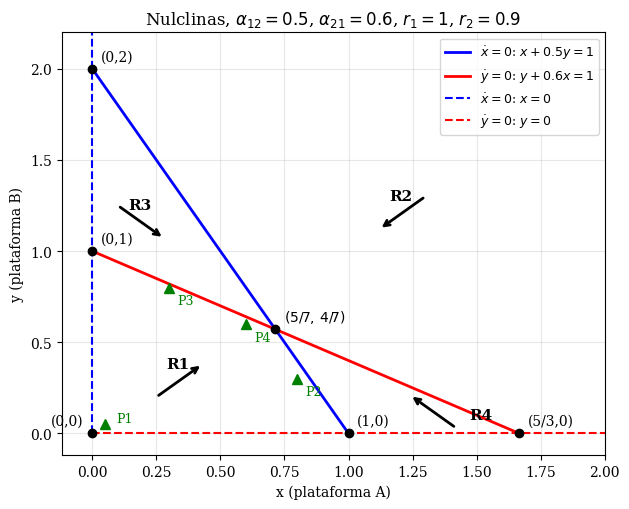

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
xx = np.linspace(0, 2, 200)

# Nulclinas no triviales, recortadas al cuadrante x, y >= 0
m1 = xx <= 1
m2 = xx <= 1 / a21
ax.plot(xx[m1], (1 - xx[m1]) / a12, 'b', lw=2, label=rf'$\dot x=0$: $x+{a12}y=1$')
ax.plot(xx[m2], 1 - a21 * xx[m2], 'r', lw=2, label=rf'$\dot y=0$: $y+{a21}x=1$')
# Nulclinas triviales = ejes invariantes (línea punteada)
ax.plot([0, 0], [0, 2.2], 'b--', lw=1.5, label=r'$\dot x=0$: $x=0$')
ax.plot([0, 2], [0, 0], 'r--', lw=1.5, label=r'$\dot y=0$: $y=0$')

# Intersecciones marcadas
inter = {'(1,0)': (1, 0), '(0,1)': (0, 1), f'(0,{1/a12:g})': (0, 1 / a12),
         '(5/3,0)': (1 / a21, 0), r'$(5/7,\,4/7)$': (xs, ys)}
for k, (a, b) in inter.items():
    ax.plot(a, b, 'ko', ms=6, zorder=5)
    ax.annotate(k, (a, b), xytext=(6, 6), textcoords='offset points', fontsize=10)
ax.plot(0, 0, 'ko', ms=6, zorder=5)
ax.annotate('(0,0)', (0, 0), xytext=(-30, 6), textcoords='offset points', fontsize=10)

# Flecha del campo en cada región: dirección según el signo de (x', y')
reg_flecha = {'R1': (0.25, 0.2), 'R2': (1.3, 1.3), 'R3': (0.1, 1.25), 'R4': (1.42, 0.03)}
for k, (a, b) in reg_flecha.items():
    u, v = campo(a, b)
    ax.annotate('', xy=(a + 0.18 * np.sign(u), b + 0.18 * np.sign(v)), xytext=(a, b),
                arrowprops=dict(arrowstyle='->', lw=2, color='k'))
    tx, ty = (a + 0.09 * np.sign(u) - 0.05, b + 0.09 * np.sign(v) + 0.07) if k != 'R4' else (1.47, 0.08)
    ax.text(tx, ty, k, fontsize=11, fontweight='bold')

# Estados iniciales de referencia
P = {'P1': (0.05, 0.05), 'P2': (0.80, 0.30), 'P3': (0.30, 0.80), 'P4': (0.60, 0.60)}
for k, (a, b) in P.items():
    ax.plot(a, b, 'g^', ms=7)
    ax.annotate(k, (a, b), xytext=(6, -12) if k != 'P1' else (8, 2), textcoords='offset points', fontsize=9, color='g')

ax.set_xlim(-0.12, 2); ax.set_ylim(-0.12, 2.2)
ax.set_xlabel('x (plataforma A)'); ax.set_ylabel('y (plataforma B)')
ax.set_title(rf'Nulclinas, $\alpha_{{12}}={a12}$, $\alpha_{{21}}={a21}$, $r_1={r1:g}$, $r_2={r2:.1f}$')
ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('nulclinas.png', dpi=200)
plt.show()

### Task 1.3c – Ubicación de los estados iniciales
Se evalúa $x_0 + \alpha_{12}y_0$ y $\alpha_{21}x_0 + y_0$: si ambos son menores que 1, el punto está en R1 (debajo de las dos nulclinas). Esto **no** es una simulación, solo ubica cada punto respecto a las rectas.

In [13]:
for k, (a, b) in P.items():
    s1, s2 = a + a12 * b, a21 * a + b
    print(f"{k} {(a, b)}:  x0 + a12*y0 = {s1:.3f},  a21*x0 + y0 = {s2:.3f}")

P1 (0.05, 0.05):  x0 + a12*y0 = 0.075,  a21*x0 + y0 = 0.080
P2 (0.8, 0.3):  x0 + a12*y0 = 0.950,  a21*x0 + y0 = 0.780
P3 (0.3, 0.8):  x0 + a12*y0 = 0.700,  a21*x0 + y0 = 0.980
P4 (0.6, 0.6):  x0 + a12*y0 = 0.900,  a21*x0 + y0 = 0.960


### Task 1.3d – Tiempo característico de recuperación
$T = 1/\min|\mathrm{Re}(\lambda)|$ sobre los valores propios del equilibrio estable.

In [14]:
lam_int = np.linalg.eigvals(jacobiana(xs, ys))
T = 1 / np.min(np.abs(lam_int.real))
print("Valores propios en (x*, y*):", np.round(lam_int, 4))
print(f"T = 1/min|Re(lambda)| = {T:.4f}")

Valores propios en (x*, y*): [-0.961  -0.2676]
T = 1/min|Re(lambda)| = 3.7372


## Task 1.4 – Verificación del análisis del compañero
Parámetros: $\alpha_{12}=1.4$, $\alpha_{21}=1.5$, $r_1=1$, $r_2=0.8$. El compañero calculó $\Delta = J_{11}J_{22} + J_{12}J_{21}$; el determinante correcto es $J_{11}J_{22} - J_{12}J_{21}$.

In [15]:
c_a12, c_a21, c_r1, c_r2 = 1.4, 1.5, 1.0, 0.8
cx = (1 - c_a12) / (1 - c_a12 * c_a21)
cy = (1 - c_a21) / (1 - c_a12 * c_a21)
Jc = np.array([[-c_r1 * cx, -c_r1 * c_a12 * cx],        # en el interior J11 = -r1 x*
               [-c_r2 * c_a21 * cy, -c_r2 * cy]])         # y J22 = -r2 y*
tau_c = np.trace(Jc)
delta_mal = Jc[0, 0] * Jc[1, 1] + Jc[0, 1] * Jc[1, 0]     # fórmula del compañero (incorrecta)
delta_bien = np.linalg.det(Jc)                             # J11 J22 - J12 J21

print(f"(x*, y*) = ({cx:.3f}, {cy:.3f})")
print("J =", np.round(Jc, 3).tolist())
print(f"tau = {tau_c:.3f}")
print(f"Delta del compañero (con +): {delta_mal:.3f}")
print(f"Delta correcto (con -):      {delta_bien:.3f}")
print(f"Comprobación r1 r2 x* y* (1 - a12 a21) = {c_r1 * c_r2 * cx * cy * (1 - c_a12 * c_a21):.3f}")
print("lambda interior =", np.round(np.linalg.eigvals(Jc), 3), "->", clasificar(tau_c, delta_bien, tau_c**2 - 4 * delta_bien))
print("lambda en (1,0) =", [-c_r1, round(c_r2 * (1 - c_a21), 3)])
print("lambda en (0,1) =", [round(c_r1 * (1 - c_a12), 3), -c_r2])

(x*, y*) = (0.364, 0.455)
J = [[-0.364, -0.509], [-0.545, -0.364]]
tau = -0.727
Delta del compañero (con +): 0.410
Delta correcto (con -):      -0.145
Comprobación r1 r2 x* y* (1 - a12 a21) = -0.145
lambda interior = [ 0.163 -0.891] -> silla
lambda en (1,0) = [-1.0, -0.4]
lambda en (0,1) = [-0.4, -0.8]
